# JTBD Analysis — ODI Opportunity Scoring & Segmentation
**Method:** Outcome-Driven Innovation (Ulwick)  
**Sample:** 989 kids, 67 desired outcomes

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Style
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
    'hot zone':              '#D85A30',
    'underserved':           '#EF9F27',
    'appropriately served':  '#1D9E75',
    'overserved':            '#378ADD',
    'seg1': '#534AB7',
    'seg2': '#D85A30',
    'seg3': '#1D9E75',
}

print('Libraries loaded.')

Libraries loaded.


## 1. Load data

In [13]:
# ── Update these paths if needed ──
SEGMENTS_FILE   = 'results_segments.csv'         # output of segment_respondents.py
OPP_OVERALL     = 'opportunity_scores.csv' # output of opportunity_scores_calculator.py
OPP_PER_SEG     = 'results_segments_opp_per_segment.csv' # output of opportunity_scores_per_segment.py

df      = pd.read_csv(SEGMENTS_FILE)
opp     = pd.read_csv(OPP_OVERALL)
opp_seg = pd.read_csv(OPP_PER_SEG)

print(f'Respondents : {len(df)}')
print(f'Segments    : {sorted(df.segment.unique())}')
print(f'Outcomes    : {len(opp)}')
df['segment'].value_counts().rename('kids').to_frame()

Respondents : 989
Segments    : [np.int64(1), np.int64(2)]
Outcomes    : 67


,kids
segment,
1,505
2,484


## 2. Overall opportunity landscape
All 67 outcomes plotted — importance vs satisfaction. Hot zone = top-left.

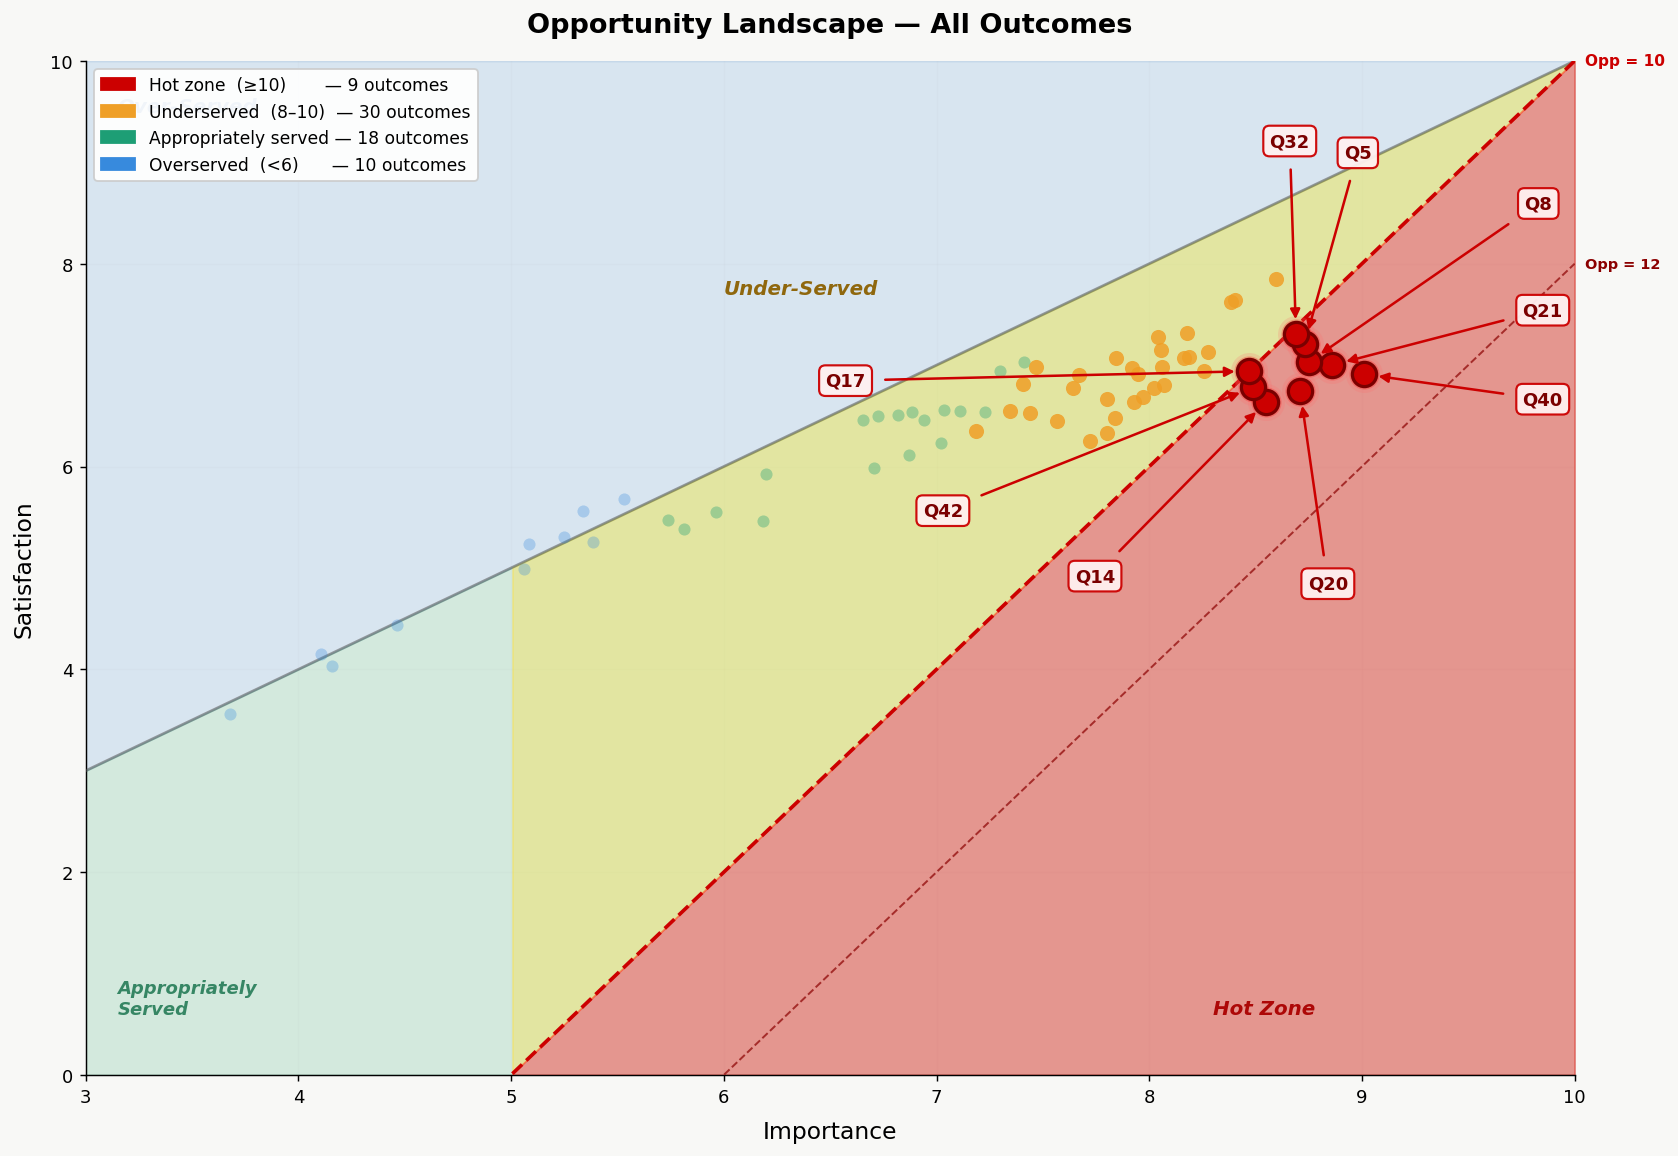

In [14]:
COLORS = {
    'hot zone':             '#CC0000',
    'underserved':          '#EF9F27',
    'appropriately served': '#1D9E75',
    'overserved':           '#378ADD',
}
SIZE = {
    'hot zone':             200,
    'underserved':          70,
    'appropriately served': 45,
    'overserved':           45,
}
ALPHA = {
    'hot zone':             1.0,
    'underserved':          0.85,
    'appropriately served': 0.35,
    'overserved':           0.3,
}

fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor('#F8F8F6')
ax.set_facecolor('#F8F8F6')

x_range = np.linspace(3, 10, 500)

# Zone backgrounds
ax.fill_between(x_range, x_range, 10, alpha=0.18, color='#4A90D9')
ax.fill_between(x_range, 0, x_range, alpha=0.18, color='#2EAA6E')
und_lower = 2 * x_range - 10
mask_und = (und_lower >= 0) & (und_lower <= x_range)
ax.fill_between(x_range[mask_und], und_lower[mask_und], x_range[mask_und],
                alpha=0.35, color='#FFE033', zorder=2)
hot_upper = 2 * x_range - 10
mask_hz = (hot_upper >= 0) & (hot_upper <= 10)
ax.fill_between(x_range[mask_hz], 0, hot_upper[mask_hz],
                alpha=0.40, color='#FF1A1A', zorder=2)

# Boundary lines
ax.plot(x_range, x_range, '-', lw=1.5, color='#555', alpha=0.55, zorder=3)
sl10 = 2 * x_range - 10
m10 = (sl10 >= 0) & (sl10 <= 10)
ax.plot(x_range[m10], sl10[m10], '--', lw=2.0, color='#CC0000', alpha=1.0, zorder=3)
ax.text(x_range[m10][-1] + 0.05, sl10[m10][-1], 'Opp = 10',
        fontsize=8.5, color='#CC0000', va='center', fontweight='bold')
sl12 = 2 * x_range - 12
m12 = (sl12 >= 0) & (sl12 <= 10)
ax.plot(x_range[m12], sl12[m12], '--', lw=1.1, color='#8B0000', alpha=0.7, zorder=3)
ax.text(x_range[m12][-1] + 0.05, sl12[m12][-1], 'Opp = 12',
        fontsize=8, color='#8B0000', va='center', fontweight='bold')

# Background zone dots
np.random.seed(42)
jitter = 0.04
for zone in ['overserved', 'appropriately served', 'underserved']:
    sub = opp[opp['zone'] == zone]
    ax.scatter(
        sub['importance'] + np.random.uniform(-jitter, jitter, len(sub)),
        sub['satisfaction'] + np.random.uniform(-jitter, jitter, len(sub)),
        c=COLORS[zone], s=SIZE[zone], alpha=ALPHA[zone], zorder=4, linewidths=0
    )

# Hot zone dots with glow
hot = opp[opp['zone'] == 'hot zone'].copy()
ax.scatter(hot['importance'], hot['satisfaction'],
           c='#FF6B6B', s=420, alpha=0.20, zorder=5, linewidths=0)
ax.scatter(hot['importance'], hot['satisfaction'],
           c='#FF2222', s=280, alpha=0.30, zorder=5, linewidths=0)
ax.scatter(hot['importance'], hot['satisfaction'],
           c='#CC0000', s=180, alpha=1.0, zorder=6, linewidths=1.8, edgecolors='#7A0000')

# Outward pointers
cx = hot['importance'].mean()
cy = hot['satisfaction'].mean()
RADIUS = 1.9
for _, row in hot.iterrows():
    px, py = row['importance'], row['satisfaction']
    dx, dy = px - cx, py - cy
    dist = np.sqrt(dx**2 + dy**2) or 1
    lx = np.clip(px + (dx / dist) * RADIUS, 3.3, 9.85)
    ly = np.clip(py + (dy / dist) * RADIUS, 0.3, 9.7)
    ax.annotate(row['outcome'],
        xy=(px, py), xytext=(lx, ly),
        fontsize=10, fontweight='bold', color='#7A0000',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#FFF0F0',
                  edgecolor='#CC0000', alpha=0.95, linewidth=1.2),
        arrowprops=dict(arrowstyle='-|>', color='#CC0000',
                        lw=1.4, mutation_scale=11, shrinkA=7, shrinkB=8),
        zorder=9)

# Zone labels
ax.text(3.15, 9.5,  'Over-Served',          fontsize=11, color='#1A5FA8', style='italic', fontweight='bold', alpha=0.85)
ax.text(3.15, 0.6,  'Appropriately\nServed', fontsize=10, color='#0F6E46', style='italic', fontweight='bold', alpha=0.8)
ax.text(6.0,  7.7,  'Under-Served',          fontsize=11, color='#8B6000', style='italic', fontweight='bold', alpha=0.95)
ax.text(8.3,  0.6,  'Hot Zone',              fontsize=11, color='#AA0000', style='italic', fontweight='bold', alpha=0.95)

# Legend
legend_handles = [
    mpatches.Patch(color='#CC0000', label=f"Hot zone  (≥10)       — {len(opp[opp.zone=='hot zone'])} outcomes"),
    mpatches.Patch(color='#EF9F27', label=f"Underserved  (8–10)  — {len(opp[opp.zone=='underserved'])} outcomes"),
    mpatches.Patch(color='#1D9E75', label=f"Appropriately served — {len(opp[opp.zone=='appropriately served'])} outcomes"),
    mpatches.Patch(color='#378ADD', label=f"Overserved  (<6)      — {len(opp[opp.zone=='overserved'])} outcomes"),
]
ax.legend(handles=legend_handles, fontsize=9.5, frameon=True,
          framealpha=0.93, edgecolor='#ccc', loc='upper left', facecolor='white')

ax.set_xlim(3, 10)
ax.set_ylim(0, 10)
ax.set_xlabel('Importance', fontsize=13, labelpad=8)
ax.set_ylabel('Satisfaction', fontsize=13, labelpad=8)
ax.set_title('Opportunity Landscape — All Outcomes', fontsize=15, fontweight='bold', pad=16)
ax.grid(True, alpha=0.06, linewidth=0.6)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('landscape_overall.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Top 30 opportunities — overall

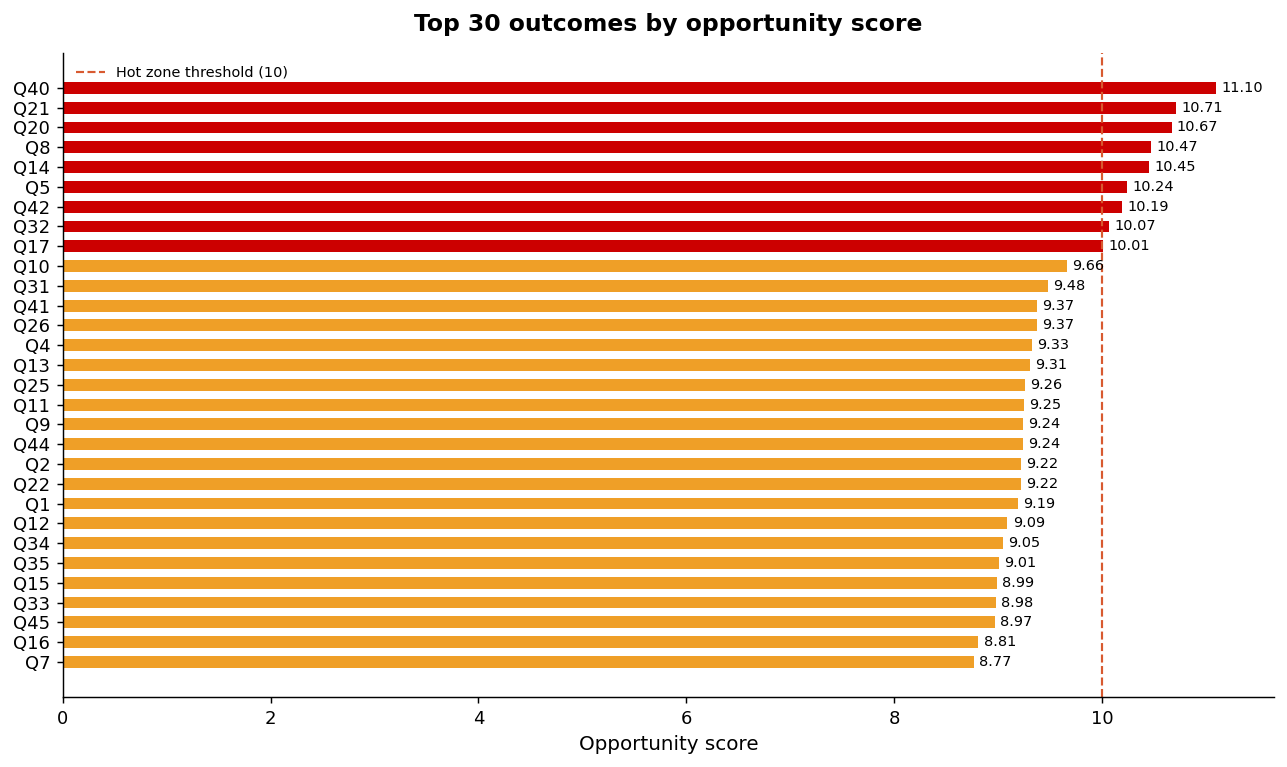

In [15]:
top30 = opp.nlargest(30, 'opportunity_score')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top30['outcome'][::-1], top30['opportunity_score'][::-1],
               color=[COLORS[z] for z in top30['zone'][::-1]], height=0.6)

ax.axvline(10, color='#D85A30', lw=1.2, ls='--', label='Hot zone threshold (10)')
ax.set_xlabel('Opportunity score', fontsize=11)
ax.set_title('Top 30 outcomes by opportunity score', fontsize=13, fontweight='bold', pad=12)

for bar, val in zip(bars, top30['opportunity_score'][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8)

ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig('top15_overall.png', bbox_inches='tight')
plt.show()

## 4. Segment profiles
Who is in each segment?

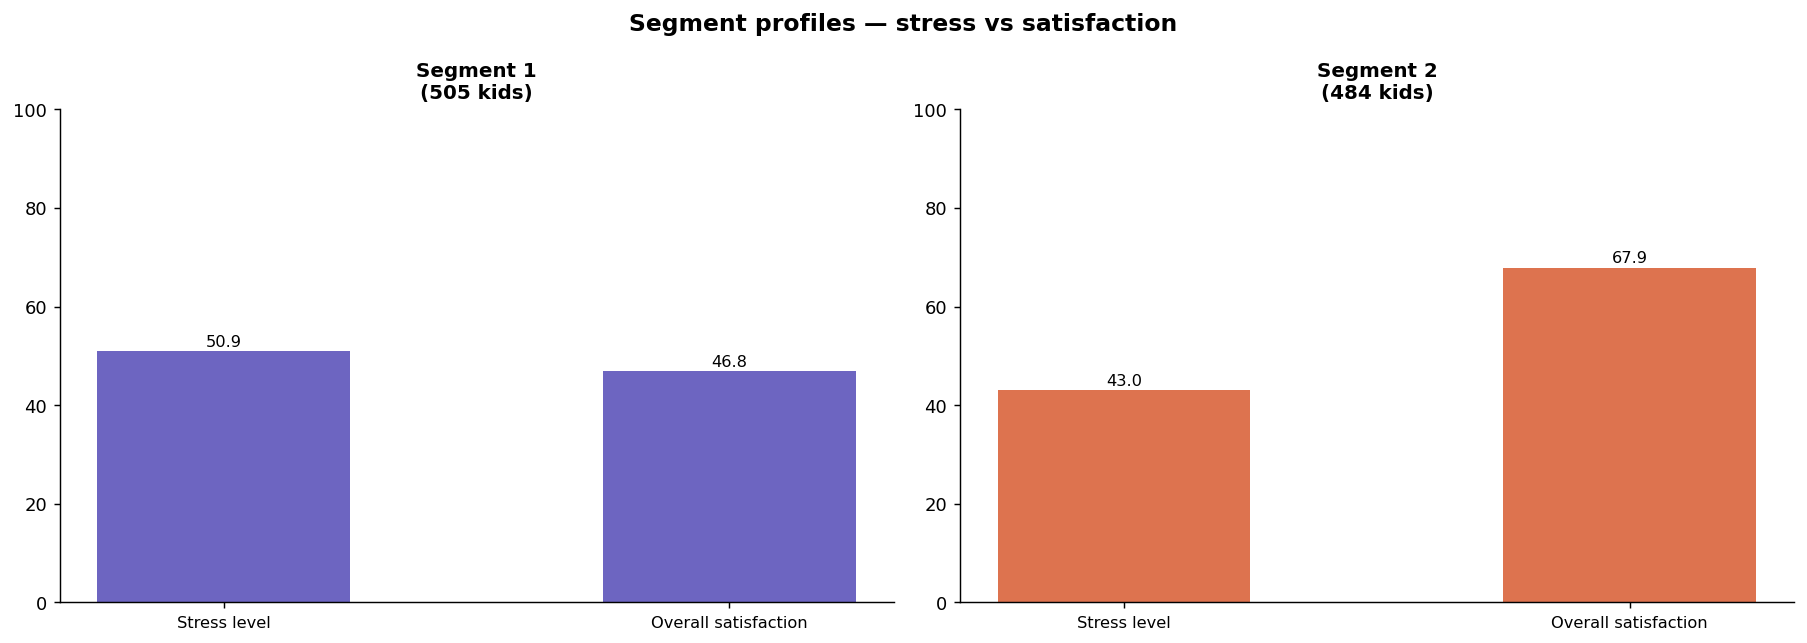

In [16]:
seg_colors = ['#534AB7', '#D85A30', '#1D9E75']
segments   = sorted(df['segment'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['stress_level', 'overall_satisfaction']
labels  = ['Stress level', 'Overall satisfaction']

for i, seg in enumerate(segments):
    seg_df = df[df['segment'] == seg]
    ax = axes[i]
    vals = [seg_df[m].mean() for m in metrics]
    bars = ax.bar(labels, vals, color=seg_colors[i], alpha=0.85, width=0.5)
    ax.set_ylim(0, 100)
    ax.set_title(f'Segment {seg}\n({len(seg_df)} kids)', fontsize=11, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}', ha='center', fontsize=9)
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle('Segment profiles — stress vs satisfaction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('segment_profiles.png', bbox_inches='tight')
plt.show()

## 5. Opportunity landscape per segment
Each segment gets its own map.

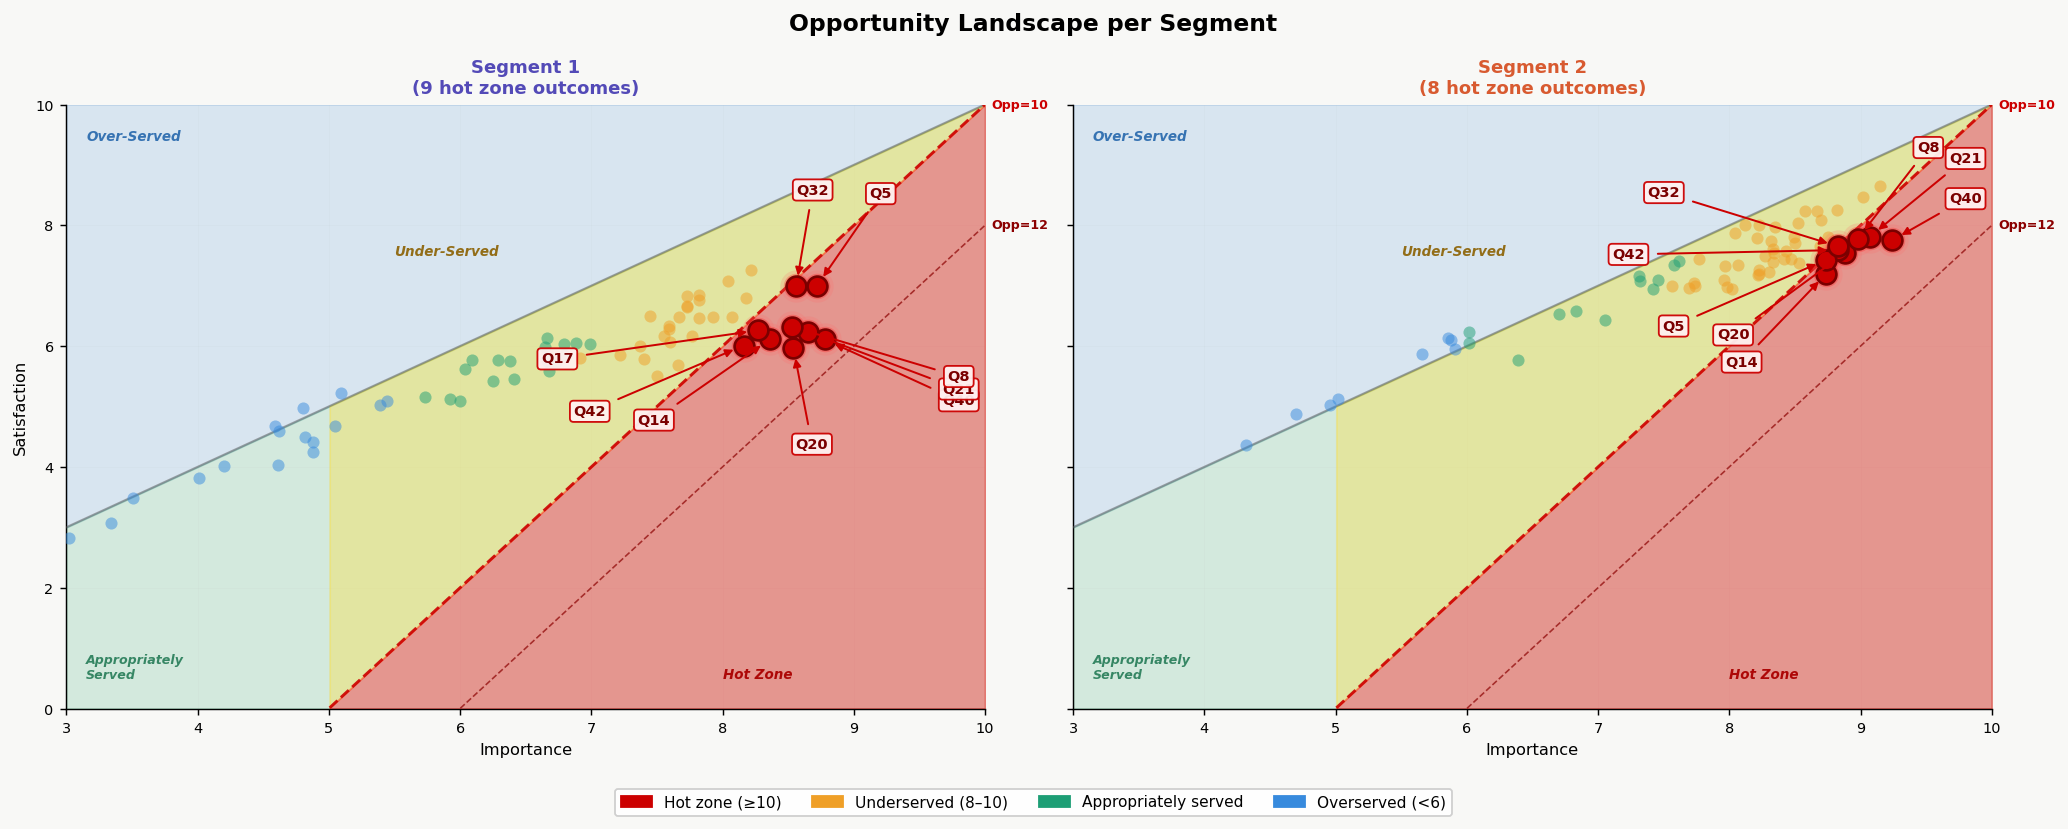

In [17]:
fig, axes = plt.subplots(1, len(segments), figsize=(16, 6), sharey=True)
fig.patch.set_facecolor('#F8F8F6')
x_range = np.linspace(3, 10, 500)

for i, seg in enumerate(segments):
    seg_opp = opp_seg[opp_seg['segment'] == seg]
    ax = axes[i]
    ax.set_facecolor('#F8F8F6')

    # Zone backgrounds
    ax.fill_between(x_range, x_range, 10, alpha=0.18, color='#4A90D9')
    ax.fill_between(x_range, 0, x_range, alpha=0.18, color='#2EAA6E')
    und_lower = 2 * x_range - 10
    mask_und = (und_lower >= 0) & (und_lower <= x_range)
    ax.fill_between(x_range[mask_und], und_lower[mask_und], x_range[mask_und],
                    alpha=0.35, color='#FFE033', zorder=2)
    hot_upper = 2 * x_range - 10
    mask_hz = (hot_upper >= 0) & (hot_upper <= 10)
    ax.fill_between(x_range[mask_hz], 0, hot_upper[mask_hz],
                    alpha=0.40, color='#FF1A1A', zorder=2)

    # Boundary lines
    ax.plot(x_range, x_range, '-', lw=1.2, color='#555', alpha=0.5, zorder=3)
    sl10 = 2 * x_range - 10
    m10 = (sl10 >= 0) & (sl10 <= 10)
    ax.plot(x_range[m10], sl10[m10], '--', lw=1.6, color='#CC0000', alpha=0.9, zorder=3)
    ax.text(x_range[m10][-1] + 0.05, sl10[m10][-1], 'Opp=10',
            fontsize=7, color='#CC0000', va='center', fontweight='bold')
    sl12 = 2 * x_range - 12
    m12 = (sl12 >= 0) & (sl12 <= 10)
    ax.plot(x_range[m12], sl12[m12], '--', lw=0.9, color='#8B0000', alpha=0.7, zorder=3)
    ax.text(x_range[m12][-1] + 0.05, sl12[m12][-1], 'Opp=12',
            fontsize=7, color='#8B0000', va='center', fontweight='bold')

    # Background zone dots
    for zone in ['overserved', 'appropriately served', 'underserved']:
        sub = seg_opp[seg_opp['zone'] == zone]
        ax.scatter(sub['importance'], sub['satisfaction'],
                   c=COLORS[zone], s=45, alpha=0.5, zorder=4, linewidths=0)

    # Hot zone dots with glow
    hot = seg_opp[seg_opp['zone'] == 'hot zone']
    if len(hot) > 0:
        ax.scatter(hot['importance'], hot['satisfaction'],
                   c='#FF6B6B', s=320, alpha=0.20, zorder=5, linewidths=0)
        ax.scatter(hot['importance'], hot['satisfaction'],
                   c='#FF2222', s=200, alpha=0.30, zorder=5, linewidths=0)
        ax.scatter(hot['importance'], hot['satisfaction'],
                   c='#CC0000', s=120, alpha=1.0, zorder=6,
                   linewidths=1.5, edgecolors='#7A0000')

        # Outward pointers for hot zone
        cx = hot['importance'].mean()
        cy = hot['satisfaction'].mean()
        RADIUS = 1.6
        for _, row in hot.iterrows():
            px, py = row['importance'], row['satisfaction']
            dx, dy = px - cx, py - cy
            dist = np.sqrt(dx**2 + dy**2) or 1
            lx = np.clip(px + (dx / dist) * RADIUS, 3.2, 9.8)
            ly = np.clip(py + (dy / dist) * RADIUS, 0.3, 9.7)
            ax.annotate(row['outcome'],
                xy=(px, py), xytext=(lx, ly),
                fontsize=8, fontweight='bold', color='#7A0000',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='#FFF0F0',
                          edgecolor='#CC0000', alpha=0.95, linewidth=1.0),
                arrowprops=dict(arrowstyle='-|>', color='#CC0000',
                                lw=1.1, mutation_scale=9, shrinkA=5, shrinkB=6),
                zorder=9)

    # Zone text labels
    ax.text(3.15, 9.4, 'Over-Served',          fontsize=7.5, color='#1A5FA8', style='italic', fontweight='bold', alpha=0.85)
    ax.text(3.15, 0.5, 'Appropriately\nServed', fontsize=7,   color='#0F6E46', style='italic', fontweight='bold', alpha=0.8)
    ax.text(5.5,  7.5, 'Under-Served',          fontsize=7.5, color='#8B6000', style='italic', fontweight='bold', alpha=0.9)
    ax.text(8.0,  0.5, 'Hot Zone',              fontsize=7.5, color='#AA0000', style='italic', fontweight='bold', alpha=0.95)

    hot_count = len(hot)
    ax.set_title(f'Segment {seg}\n({hot_count} hot zone outcomes)',
                 fontsize=10, fontweight='bold', color=seg_colors[i])
    ax.set_xlabel('Importance', fontsize=9)
    ax.set_xlim(3, 10)
    ax.set_ylim(0, 10)
    ax.grid(True, alpha=0.06, linewidth=0.5)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.set_ylabel('Satisfaction', fontsize=9)

legend_handles = [
    mpatches.Patch(color='#CC0000', label='Hot zone (≥10)'),
    mpatches.Patch(color='#EF9F27', label='Underserved (8–10)'),
    mpatches.Patch(color='#1D9E75', label='Appropriately served'),
    mpatches.Patch(color='#378ADD', label='Overserved (<6)'),
]
fig.legend(handles=legend_handles, fontsize=8.5, frameon=True,
           framealpha=0.93, edgecolor='#ccc', facecolor='white',
           loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.06))
fig.suptitle('Opportunity Landscape per Segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('landscape_per_segment.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Name your segments
Based on the profiles and opportunity landscapes above, we give each segment a name and description.

We name based on this structure:
- **Name** 
- **Who they are** 
- **What they need most** 
- **Design implication** 

In [41]:
# ── Fill these in after looking at the charts above ──

segment_names = {
    1: "Ambitious Performance Seekers",
    2: "Safety and Support Seekers",
    3: "Team-Oriented Growth Seekers",
}

segment_descriptions = {
    1: "Performance-oriented players who want to compete regularly, win games and visibly improve their skills. They need a structured and serious training environment, clear guidance from the coach and better support in achieving measurable sporting progress.",
    2: "Players with relatively high stress who need psychological safety and respectful treatment within the team. They want to make mistakes without being shouted at, embarrassed or publicly criticized, and they need clear, constructive feedback that helps them improve",
    3: "Generally satisfied and low-stress players who still want to compete, develop and improve their performance. At the same time, they value a respectful, fair and cooperative team environment where teammates support one another and social connection is encouraged.",
}

# Print summary card per segment
for seg in segments:
    seg_df  = df[df['segment'] == seg]
    seg_opp = opp_seg[opp_seg['segment'] == seg]
    top3    = seg_opp.nlargest(3, 'opportunity_score')
    hot     = len(seg_opp[seg_opp['zone'] == 'hot zone'])

    print(f"{'='*50}")
    print(f"SEGMENT {seg} — {segment_names[seg]}")
    print(f"  Kids        : {len(seg_df)} ({len(seg_df)/len(df)*100:.1f}%)")
    print(f"  Avg age     : {seg_df['age'].mean():.1f}")
    print(f"  Stress      : {seg_df['stress_level'].mean():.1f}")
    print(f"  Satisfaction: {seg_df['overall_satisfaction'].mean():.1f}")
    print(f"  Hot zone    : {hot} outcomes")
    print(f"  Top needs   :")
    for _, row in top3.iterrows():
        print(f"    {row.outcome}: {row.opportunity_score:.2f} ({row.zone})")
    print(f"  Description : {segment_descriptions[seg]}")
print('='*50)

SEGMENT 1 — Ambitious Performance Seekers
  Kids        : 505 (51.1%)
  Avg age     : 11.3
  Stress      : 50.9
  Satisfaction: 46.8
  Hot zone    : 9 outcomes
  Top needs   :
    Q40: 11.45 (hot zone)
    Q20: 11.11 (hot zone)
    Q21: 11.07 (hot zone)
  Description : Performance-oriented players who want to compete regularly, win games and visibly improve their skills. They need a structured and serious training environment, clear guidance from the coach and better support in achieving measurable sporting progress.
SEGMENT 2 — Safety and Support Seekers
  Kids        : 484 (48.9%)
  Avg age     : 10.9
  Stress      : 43.0
  Satisfaction: 67.9
  Hot zone    : 8 outcomes
  Top needs   :
    Q40: 10.74 (hot zone)
    Q21: 10.34 (hot zone)
    Q14: 10.28 (hot zone)
  Description : Players with relatively high stress who need psychological safety and respectful treatment within the team. They want to make mistakes without being shouted at, embarrassed or publicly criticized, and they need

## 9. Final summary — what should the club do?
- Still in progress ...